In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '.')
import ModuloACP as macp
%matplotlib inline

In [13]:
# Cargar datos — separador ';', decimal ',' (formato europeo), primera columna como índice
datos = pd.read_csv('ejemplo_estudiantes.csv', sep=';', decimal=',', index_col=0)
print('Dimensiones:', datos.shape)
datos

Dimensiones: (10, 5)


,Matematicas,Ciencias,Espanol,Historia,EdFisica
Lucia,7.0,6.5,9.2,8.6,8.0
Pedro,7.5,9.4,7.3,7.0,7.0
Ines,7.6,9.2,8.0,8.0,7.5
Luis,5.0,6.5,6.5,7.0,9.0
Andres,6.0,6.0,7.8,8.9,7.3
Ana,7.8,9.6,7.7,8.0,6.5
Carlos,6.3,6.4,8.2,9.0,7.2
Jose,7.9,9.7,7.5,8.0,6.0
Sonia,6.0,6.0,6.5,5.5,8.7
Maria,6.8,7.2,8.7,9.0,7.0


In [14]:
# Crear el modelo ACP con 5 componentes (uno por cada variable)
acp = macp.ACP(datos, n_componentes=5)

In [15]:
# Varianza explicada por cada componente principal
var = acp.var_explicada
print('Varianza explicada por componente (%)')
for i, v in enumerate(var):
    print(f'  Componente {i}: {round(v, 2)}%')
print(f'\nVarianza acumulada (C0 + C1): {round(var[0] + var[1], 2)}%')

Varianza explicada por componente (%)
  Componente 0: 57.86%
  Componente 1: 32.57%
  Componente 2: 6.93%
  Componente 3: 2.45%
  Componente 4: 0.18%

Varianza acumulada (C0 + C1): 90.44%


In [16]:
# Correlación de las variables originales con cada componente principal
print('Correlación de variables con los componentes:')
acp.correlacion_var

Correlación de variables con los componentes:


component,0,1,2,3,4
variable,,,,,
Matematicas,-0.895798,-0.345204,0.257979,-0.091468,-0.058828
Ciencias,-0.722798,-0.648395,0.023840,0.235878,0.030682
Espanol,-0.610893,0.717321,0.331025,-0.024542,0.045615
Historia,-0.599923,0.748470,-0.232063,0.156397,-0.039644
EdFisica,0.913926,0.119637,0.340651,0.183154,-0.028929


In [17]:
# Coordenadas de los individuos (estudiantes) en el plano principal
print('Coordenadas de los estudiantes:')
acp.coordenadas_ind

Coordenadas de los estudiantes:


component,0,1,2,3,4
Lucia,-0.323063,1.772525,1.198801,-0.055015,-0.003633
Pedro,-0.665441,-1.638702,0.145476,-0.023065,0.123377
Ines,-1.002547,-0.515692,0.628888,0.516444,-0.142876
Luis,3.172095,-0.262782,-0.381960,0.677777,0.062504
Andres,0.488868,1.365402,-0.835236,-0.155792,-0.123367
Ana,-1.708633,-1.021700,-0.127077,0.066833,-0.025292
Carlos,-0.067586,1.462336,-0.506240,-0.117928,-0.013124
Jose,-2.011855,-1.275865,-0.542150,-0.197787,-0.017434
Sonia,3.042030,-1.254881,0.448829,-0.639999,-0.037885
Maria,-0.923869,1.369359,-0.029330,-0.071467,0.177730


In [18]:
# Contribución de cada individuo a los componentes
print('Contribución de los estudiantes a los componentes:')
acp.contribucion_ind

Contribución de los estudiantes a los componentes:


component,0,1,2,3,4
Lucia,0.003607,0.192911,0.414639,0.002468,0.000148
Pedro,0.015305,0.164882,0.006106,0.000434,0.171199
Ines,0.034740,0.016329,0.114110,0.217526,0.229587
Luis,0.347781,0.004240,0.042093,0.374661,0.043938
Andres,0.008260,0.114470,0.201277,0.019795,0.171171
Ana,0.100905,0.064094,0.004659,0.003643,0.007194
Carlos,0.000158,0.131301,0.073942,0.011342,0.001937
Jose,0.139897,0.099950,0.084804,0.031905,0.003418
Sonia,0.319846,0.096689,0.058122,0.334059,0.016142
Maria,0.029501,0.115135,0.000248,0.004166,0.355265


In [19]:
# Calidad de representación (cos²) de cada individuo
print('Calidad de representación (cos²):')
acp.cos2_ind

Calidad de representación (cos²):


component,0,1,2,3,4
Lucia,0.022271,0.670421,0.306660,0.000646,0.000003
Pedro,0.139906,0.848431,0.006687,0.000168,0.004809
Ines,0.514469,0.136123,0.202440,0.136520,0.010449
Luis,0.936852,0.006429,0.013584,0.042771,0.000364
Andres,0.084140,0.656354,0.245604,0.008545,0.005358
Ana,0.732686,0.261980,0.004053,0.001121,0.000161
Carlos,0.001893,0.886081,0.106192,0.005763,0.000071
Jose,0.673612,0.270910,0.048917,0.006510,0.000051
Sonia,0.808830,0.137637,0.017607,0.035800,0.000125
Maria,0.308554,0.677869,0.000311,0.001846,0.011419


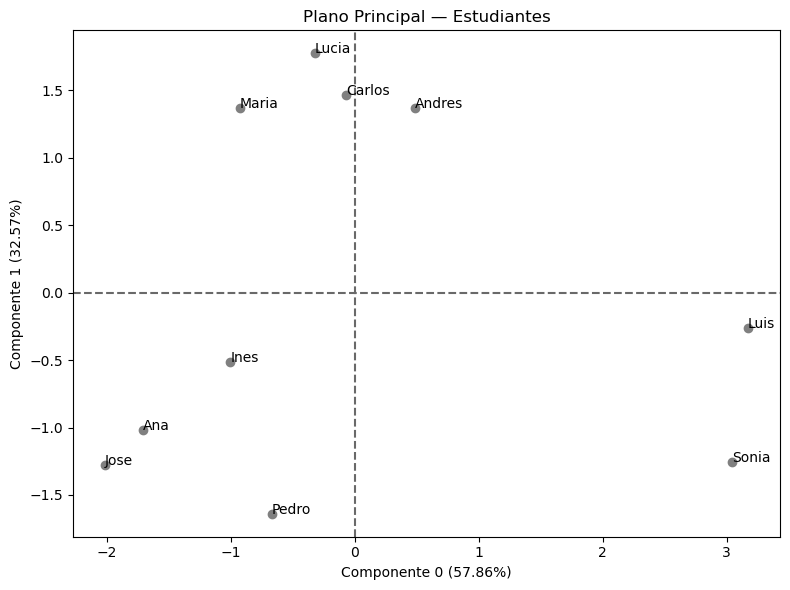

In [20]:
# Plano principal: posición de los estudiantes sobre los dos primeros componentes
plt.figure(figsize=(8, 6))
acp.plot_plano_principal(ejes=[0, 1], ind_labels=True, titulo='Plano Principal — Estudiantes')
plt.tight_layout()
plt.show()

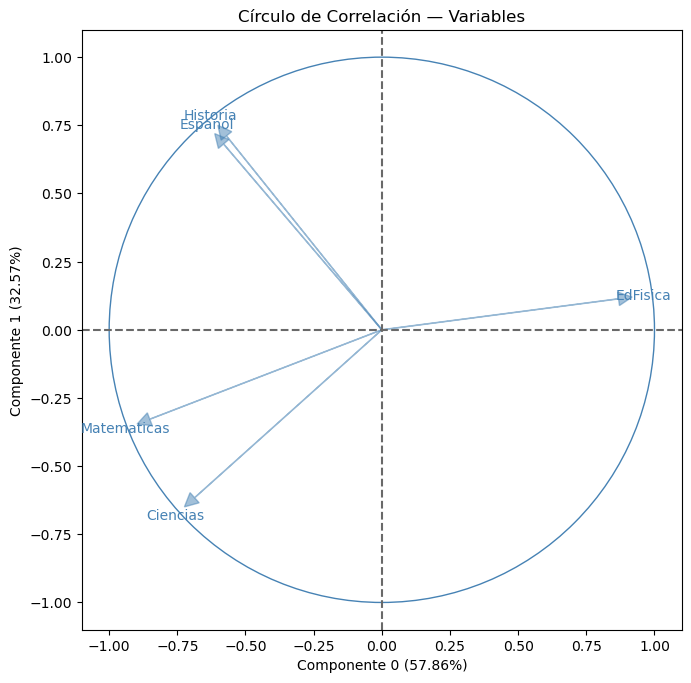

In [21]:
# Círculo de correlación: relación de las variables con los componentes
plt.figure(figsize=(7, 7))
acp.plot_circulo(ejes=[0, 1], var_labels=True, titulo='Círculo de Correlación — Variables')
plt.tight_layout()
plt.show()

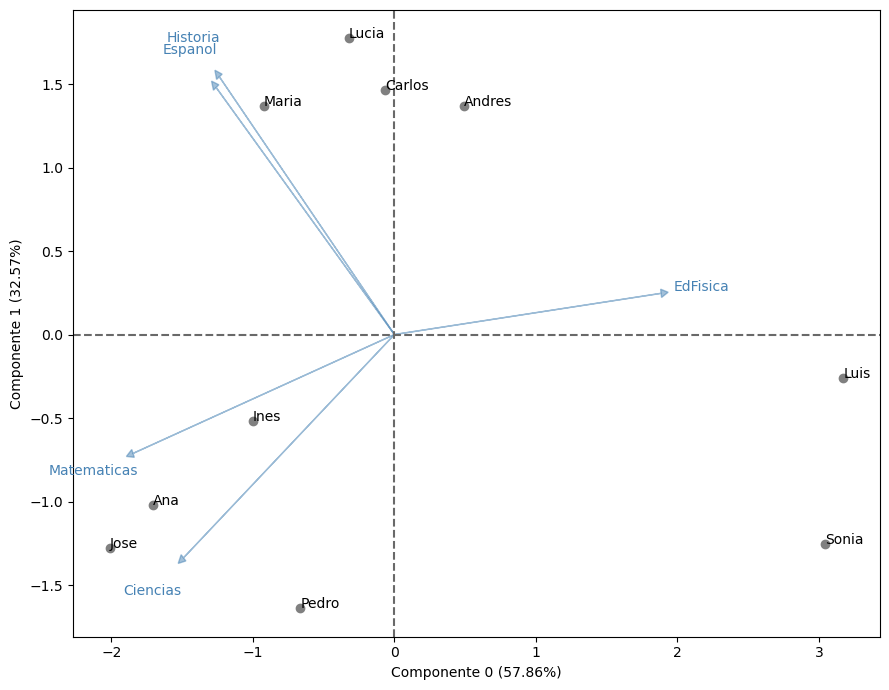

In [23]:
# Sobreposición: estudiantes y variables en el mismo plano
plt.figure(figsize=(9, 7))
acp.plot_sobreposicion(ejes=[0, 1], ind_labels=True, var_labels=True, titulo='Sobreposición Plano-Círculo — Estudiantes y Variables')
plt.tight_layout()
plt.show()